In [1]:
#EDA thời gian và không gian
%matplotlib inline
%pip install seaborn
import os, re, warnings, textwrap, gc
from collections import defaultdict
 
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
 
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None
 
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
 
COLOR_PRIMARY = '#2563EB'
COLOR_WARN    = '#DC2626'
 
# ─── CẤU HÌNH ───
HDFS_DIR = "hdfs://hadoop-master:9000/user/data/raw"
RAW_DATA_GLOB = f"{HDFS_DIR}/yellow_tripdata_*.parquet"
ZONE_LOOKUP_PATH = f"{HDFS_DIR}/taxi_zone_lookup.csv"
OUT_DIR  = "eda_output"
YEARS    = range(2020, 2026)
MONTHS   = range(1, 13)
PICKUP_COL_CANDIDATES = ["tpep_pickup_datetime", "pickup_datetime"]
PU_COL = "PULocationID"
DO_COL = "DOLocationID"
 
os.makedirs(OUT_DIR, exist_ok=True)
 
# ─── SPARK SESSION ───
spark = (
    SparkSession.builder
    .appName("TaxiEDA_HDFS")
    .master("yarn")
    .config("spark.submit.deployMode", "client")
    .config("spark.eventLog.enabled", "true")
    .config("spark.executor.instances", "2")
    .config("spark.executor.cores", "3")
    .config("spark.executor.memory", "8g")
    .config("spark.executor.memoryOverhead", "2g")
    .config("spark.driver.memory", "4g")
    .config("spark.driver.memoryOverhead", "1g")
    .config("spark.sql.shuffle.partitions", "12")
    .config("spark.sql.parquet.mergeSchema", "true")
    .config("spark.sql.parquet.enableVectorizedReader", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
 
hadoop = spark._jvm.org.apache.hadoop
conf   = spark._jsc.hadoopConfiguration()
fs     = hadoop.fs.FileSystem.get(conf)
 
def read_raw_trip_file(path, year=None):
    df_tmp = spark.read.parquet(path)
    pickup_col = next((c for c in PICKUP_COL_CANDIDATES if c in df_tmp.columns), None)
    required_cols = [pickup_col, PU_COL, DO_COL]
    if pickup_col is None or any(c not in df_tmp.columns for c in [PU_COL, DO_COL]):
        missing = [c for c in required_cols if c is None or c not in df_tmp.columns]
        raise ValueError(f"Missing required columns: {missing}")
 
    sdf = (
        df_tmp.select(
            F.col(pickup_col).cast("timestamp").alias("pickup_dt"),
            F.col(PU_COL).cast("int").alias("PU"),
            F.col(DO_COL).cast("int").alias("DO"),
        )
        .filter(F.col("pickup_dt").isNotNull())
    )
    if year is not None:
        sdf = sdf.filter(F.year("pickup_dt") == year)
    return sdf
 
print("[OK] Spark session:", spark.sparkContext.appName)

Note: you may need to restart the kernel to use updated packages.


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/31 05:46:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/31 05:46:13 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


[OK] Spark session: TaxiEDA_HDFS


In [2]:
# PHẦN 0 -- ÁNH XẠ TAXI ZONE -> QUẬN (BOROUGH)
zone_csv_path = ZONE_LOOKUP_PATH
df_zones = spark.read.csv(zone_csv_path, header=True, inferSchema=True).toPandas()
df_zones["Borough"] = df_zones["Borough"].fillna("Unknown")
df_zones["Zone"]    = df_zones["Zone"].fillna("Unknown")
 
BOROUGH_MAP = dict(zip(df_zones["LocationID"], df_zones["Borough"]))
ZONE_MAP    = dict(zip(df_zones["LocationID"], df_zones["Zone"]))
 
def get_borough(lid):
    return BOROUGH_MAP.get(lid, "Unknown")
 
def get_zone_name(lid):
    return ZONE_MAP.get(lid, f"Zone {lid}")
 
print(f"[OK] Đã nạp {len(df_zones)} taxi zones")
 

[OK] Đã nạp 265 taxi zones


In [3]:
# PHẦN 1 -- TỔNG QUAN: Quét file, Schema, Thống kê
print(" PHẦN 1 -- TỔNG QUAN: NHẬN BIẾT & THỐNG KÊ")
 
# 1a. Quét file trên HDFS bằng glob giống notebook feature engineering
file_records = []
all_paths = []
file_status = fs.globStatus(hadoop.fs.Path(RAW_DATA_GLOB))
if not file_status:
    raise ValueError(f"No raw parquet files found for {RAW_DATA_GLOB}")
 
for status in sorted(file_status, key=lambda s: s.getPath().getName()):
    fpath = status.getPath().toString()
    fname = status.getPath().getName()
    match = re.search(r"yellow_tripdata_(\d{4})-(\d{2})\.parquet$", fname)
    if not match:
        print(f"  Bỏ qua file không đúng mẫu tên: {fpath}")
        continue
    year, month = int(match.group(1)), int(match.group(2))
    if year not in YEARS or month not in MONTHS:
        continue
    size_mb = status.getLen() / (1024 * 1024)
    all_paths.append(fpath)
    file_records.append({
        "filename": fname, "path": fpath,
        "year": year, "month": month,
        "size_mb": round(size_mb, 2),
    })
 
df_files = pd.DataFrame(file_records).sort_values(["year", "month"]).reset_index(drop=True)
if df_files.empty:
    raise ValueError(f"No raw parquet files matched years/months under {HDFS_DIR}")
total_size_gb = df_files["size_mb"].sum() / 1024
 
print(f"  Số file tìm thấy        : {len(df_files)}")
print(f"  Khoảng thời gian         : {df_files['year'].min()} - {df_files['year'].max()}")
print(f"  Tổng dung lượng (HDFS)   : {total_size_gb:.3f} GB")
 
# 1b. Schema từ file đầu tiên
first_sdf = spark.read.parquet(all_paths[0])
print(f"\nSchema (từ {os.path.basename(all_paths[0])}):")
print("-" * 55)
for i, field in enumerate(first_sdf.schema.fields):
    print(f"  {i+1:2d}. {field.name:<30s} {str(field.dataType)}")
 
# 1c. Mẫu dữ liệu
print(f"\nMẫu dữ liệu (5 dòng đầu):")
sample_pdf = first_sdf.limit(5).toPandas()
print(sample_pdf.to_string(index=False, max_colwidth=25))
del first_sdf

 PHẦN 1 -- TỔNG QUAN: NHẬN BIẾT & THỐNG KÊ
  Số file tìm thấy        : 72
  Khoảng thời gian         : 2020 - 2025
  Tổng dung lượng (HDFS)   : 3.379 GB



Schema (từ yellow_tripdata_2020-01.parquet):
-------------------------------------------------------
   1. VendorID                       LongType()
   2. tpep_pickup_datetime           TimestampNTZType()
   3. tpep_dropoff_datetime          TimestampNTZType()
   4. passenger_count                DoubleType()
   5. trip_distance                  DoubleType()
   6. RatecodeID                     DoubleType()
   7. store_and_fwd_flag             StringType()
   8. PULocationID                   LongType()
   9. DOLocationID                   LongType()
  10. payment_type                   LongType()
  11. fare_amount                    DoubleType()
  12. extra                          DoubleType()
  13. mta_tax                        DoubleType()
  14. tip_amount                     DoubleType()
  15. tolls_amount                   DoubleType()
  16. improvement_surcharge          DoubleType()
  17. total_amount                   DoubleType()
  18. congestion_surcharge           DoubleT

 VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_amount  improvement_surcharge  total_amount  congestion_surcharge  airport_fee
        1  2020-01-01 00:28:15   2020-01-01 00:33:03              1.0            1.2         1.0                  N           238           239             1          6.0    3.0      0.5        1.47           0.0                    0.3         11.27                   2.5          NaN
        1  2020-01-01 00:35:39   2020-01-01 00:43:04              1.0            1.2         1.0                  N           239           238             1          7.0    3.0      0.5        1.50           0.0                    0.3         12.30                   2.5          NaN
        1  2020-01-01 00:47:41   2020-01-01 00:53:52              1.0            0.6         1.0                  N           238           238  

 ĐANG XỬ LÝ TỪNG FILE 


  [  1/72] yellow_tripdata_2020-01.parquet:  6,404,844 dòng  OK


  [  2/72] yellow_tripdata_2020-02.parquet:  6,299,336 dòng  OK


  [  3/72] yellow_tripdata_2020-03.parquet:  3,007,670 dòng  OK
  [  4/72] yellow_tripdata_2020-04.parquet:    238,072 dòng  OK


  [  5/72] yellow_tripdata_2020-05.parquet:    348,411 dòng  OK
  [  6/72] yellow_tripdata_2020-06.parquet:    549,794 dòng  OK


...

  [ 68/72] yellow_tripdata_2025-08.parquet:  3,574,090 dòng  OK


  [ 69/72] yellow_tripdata_2025-09.parquet:  4,251,015 dòng  OK


  [ 70/72] yellow_tripdata_2025-10.parquet:  4,428,699 dòng  OK


  [ 71/72] yellow_tripdata_2025-11.parquet:  4,181,441 dòng  OK


  [ 72/72] yellow_tripdata_2025-12.parquet:  4,305,006 dòng  OK

[OK] Hoàn tất xử lý từng file.

Tổng số chuyến đi: 223,410,642
Trung bình mỗi file: 3,102,926
Ít nhất: 238,072 | Nhiều nhất: 6,404,844

Tổng hợp theo năm:
 year  files  total_rows  total_size_mb     avg_rows
 2020     12    24648812         357.25 2.054068e+06
 2021     12    30903934         457.36 2.575328e+06
 2022     12    39655537         586.60 3.304628e+06
 2023     12    38310122         606.30 3.192510e+06
 2024     12    41169664         660.92 3.430805e+06
 2025     12    48722573         791.53 4.060214e+06


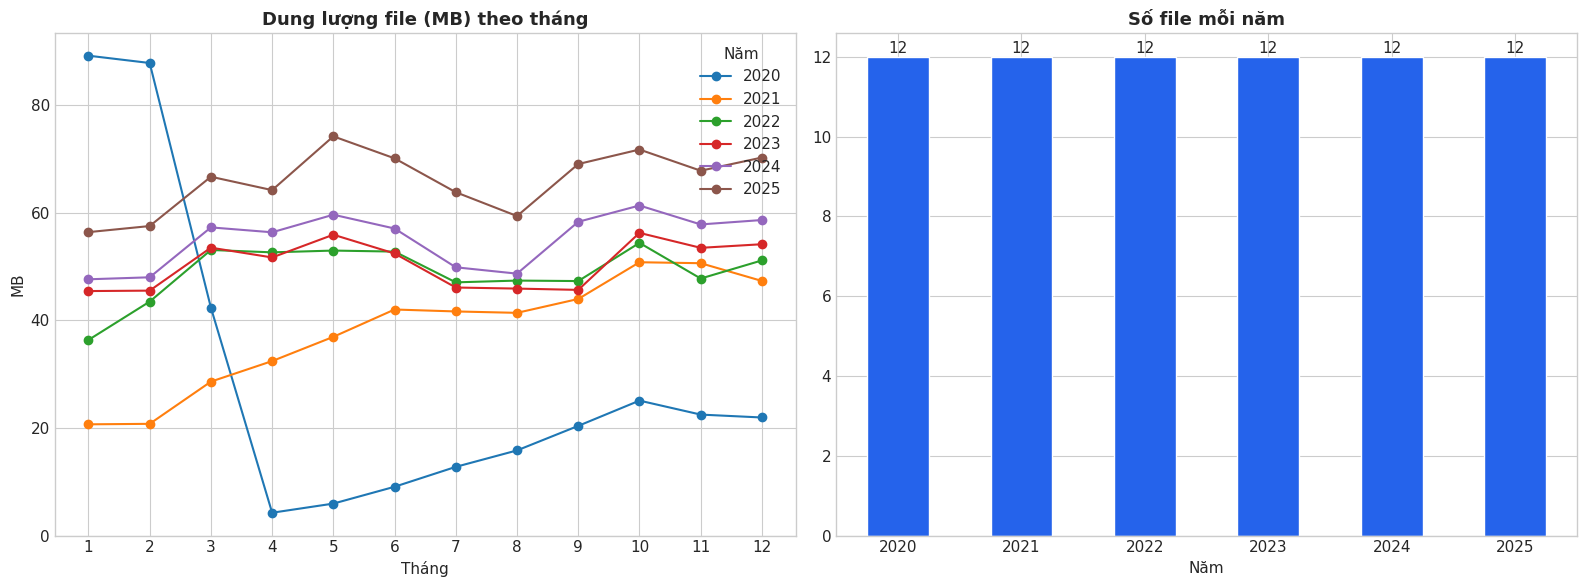

In [4]:
# XỬ LÝ TỪNG FILE: đọc -> aggregate -> thu kết quả nhỏ -> giải phóng
print(" ĐANG XỬ LÝ TỪNG FILE ")
 
# Các accumulator để gom kết quả
file_row_counts = []         # (year, month, row_count)
hourly_agg   = defaultdict(int)   # hr -> count
dow_agg      = defaultdict(int)   # dow -> count
monthly_agg  = defaultdict(int)   # mon -> count
year_hour_agg = defaultdict(int)  # (yr, hr) -> count
 
pu_agg       = defaultdict(int)   # PULocationID -> count
do_agg       = defaultdict(int)   # DOLocationID -> count
route_agg    = defaultdict(int)   # (PU, DO) -> count
 
borough_pu_year_agg = defaultdict(int)  # (yr, borough) -> count
borough_do_year_agg = defaultdict(int)  # (yr, borough) -> count
borough_od_agg      = defaultdict(int)  # (pu_borough, do_borough) -> count
 
for idx, row in df_files.iterrows():
    fpath = row["path"]
    yr    = row["year"]
    mon   = row["month"]
    fname = row["filename"]
 
    try:
        # Đọc 1 file raw, chỉ lấy/cast cột cần thiết ngay như notebook GCP
        sdf = read_raw_trip_file(fpath, year=yr)
 
        # --- Đếm số dòng ---
        cnt = sdf.count()
        file_row_counts.append((yr, mon, cnt))
 
        # --- Thời gian: group by giờ, thứ ---
        time_agg = sdf.select(
            F.hour("pickup_dt").alias("hr"),
            F.dayofweek("pickup_dt").alias("dow"),
        ).groupBy("hr", "dow").count().toPandas()
 
        for _, r in time_agg.iterrows():
            h, d, c = int(r["hr"]), int(r["dow"]), int(r["count"])
            hourly_agg[h] += c
            dow_agg[d] += c
            monthly_agg[mon] += c
            year_hour_agg[(yr, h)] += c
 
        # --- Không gian: PU, DO, tuyến đường, quận ---
        geo_agg = sdf.groupBy("PU", "DO").count().toPandas()
 
        for _, r in geo_agg.iterrows():
            pu_id, do_id, c = int(r["PU"]), int(r["DO"]), int(r["count"])
            pu_agg[pu_id] += c
            do_agg[do_id] += c
            route_agg[(pu_id, do_id)] += c
 
            b_pu = get_borough(pu_id)
            b_do = get_borough(do_id)
            borough_pu_year_agg[(yr, b_pu)] += c
            borough_do_year_agg[(yr, b_do)] += c
            borough_od_agg[(b_pu, b_do)] += c
 
        # Giải phóng bộ nhớ
        sdf.unpersist()
        del sdf, time_agg, geo_agg
        gc.collect()
 
        print(f"  [{idx+1:3d}/{len(df_files)}] {fname}: {cnt:>10,} dòng  OK")
 
    except Exception as e:
        file_row_counts.append((yr, mon, 0))
        print(f"  [{idx+1:3d}/{len(df_files)}] {fname}: LỖI -- {e}")
 
print("\n[OK] Hoàn tất xử lý từng file.")
 
# Gán row_count vào df_files
rc_df = pd.DataFrame(file_row_counts, columns=["year", "month", "row_count"])
df_files = df_files.merge(rc_df, on=["year", "month"], how="left")
df_files["row_count"] = df_files["row_count"].fillna(0).astype(int)
 
total_rows = df_files["row_count"].sum()
print(f"\nTổng số chuyến đi: {total_rows:,}")
print(f"Trung bình mỗi file: {df_files['row_count'].mean():,.0f}")
print(f"Ít nhất: {df_files['row_count'].min():,} | Nhiều nhất: {df_files['row_count'].max():,}")
 
# Bảng tổng hợp theo năm
summary_year = df_files.groupby("year").agg(
    files=("filename", "count"),
    total_rows=("row_count", "sum"),
    total_size_mb=("size_mb", "sum"),
    avg_rows=("row_count", "mean"),
).reset_index()
print("\nTổng hợp theo năm:")
print(summary_year.to_string(index=False))
 
df_files.to_csv(os.path.join(OUT_DIR, "01_file_inventory.csv"), index=False)
summary_year.to_csv(os.path.join(OUT_DIR, "01_summary_by_year.csv"), index=False)
 
# Biểu đồ tổng quan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
for year in sorted(df_files["year"].unique()):
    sub = df_files[df_files["year"] == year].sort_values("month")
    axes[0].plot(sub["month"], sub["size_mb"], marker="o", label=str(year))
axes[0].set_title("Dung lượng file (MB) theo tháng")
axes[0].set_xlabel("Tháng"); axes[0].set_ylabel("MB")
axes[0].set_xticks(range(1, 13)); axes[0].legend(title="Năm")
 
file_per_year = df_files.groupby("year")["filename"].count()
file_per_year.plot(kind="bar", ax=axes[1], color=COLOR_PRIMARY, edgecolor="white")
for i, v in enumerate(file_per_year):
    axes[1].text(i, v + 0.1, str(v), ha="center", fontsize=11)
axes[1].set_title("Số file mỗi năm"); axes[1].set_xlabel("Năm")
axes[1].tick_params(axis="x", rotation=0)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "01_overview.png"), dpi=150)
plt.show()

### Nhận xét Dữ liệu Yellow Taxi NYC (Giai đoạn 2020 - 2025)

**1. Cú sốc COVID-19 (Năm 2020):**
* Lượng chuyến đi rất cao vào tháng 1 và 2/2020 (đường màu xanh dương).
* Tuy nhiên, dữ liệu "chạm đáy" và tụt dốc không phanh vào tháng 4. 
* **Ý nghĩa:** Điều này phản ánh chính xác thời điểm New York thực hiện phong tỏa (lockdown) do đại dịch.

**2. Sự phục hồi mạnh mẽ (2021 - 2025):**
* Tổng số chuyến taxi (`total_rows`) tăng liên tục và đều đặn qua từng năm. 
* Nếu năm 2020 cả năm chỉ có khoảng **24.6 triệu chuyến**, thì đến năm 2025 con số này đã đạt mức gần **48.7 triệu chuyến** (tăng gần gấp đôi). 
* **Ý nghĩa:** Cho thấy thành phố đã mở cửa hoàn toàn và hoạt động đi lại nhộn nhịp trở lại.

**3. Chu kỳ mùa vụ ổn định:**
* Từ năm 2021 trở đi, xu hướng đi taxi các tháng trong năm bắt đầu lặp lại một cách đồng nhất. 
* **Mùa thấp điểm:** Lượng khách thường chững lại hoặc giảm nhẹ vào giữa mùa hè (**tháng 7, tháng 8**).
* **Mùa cao điểm:** Đạt đỉnh vào các tháng mùa thu và dịp lễ cuối năm (**tháng 9, tháng 10**).

 PHẦN 2 -- PHÂN TÍCH THỜI GIAN


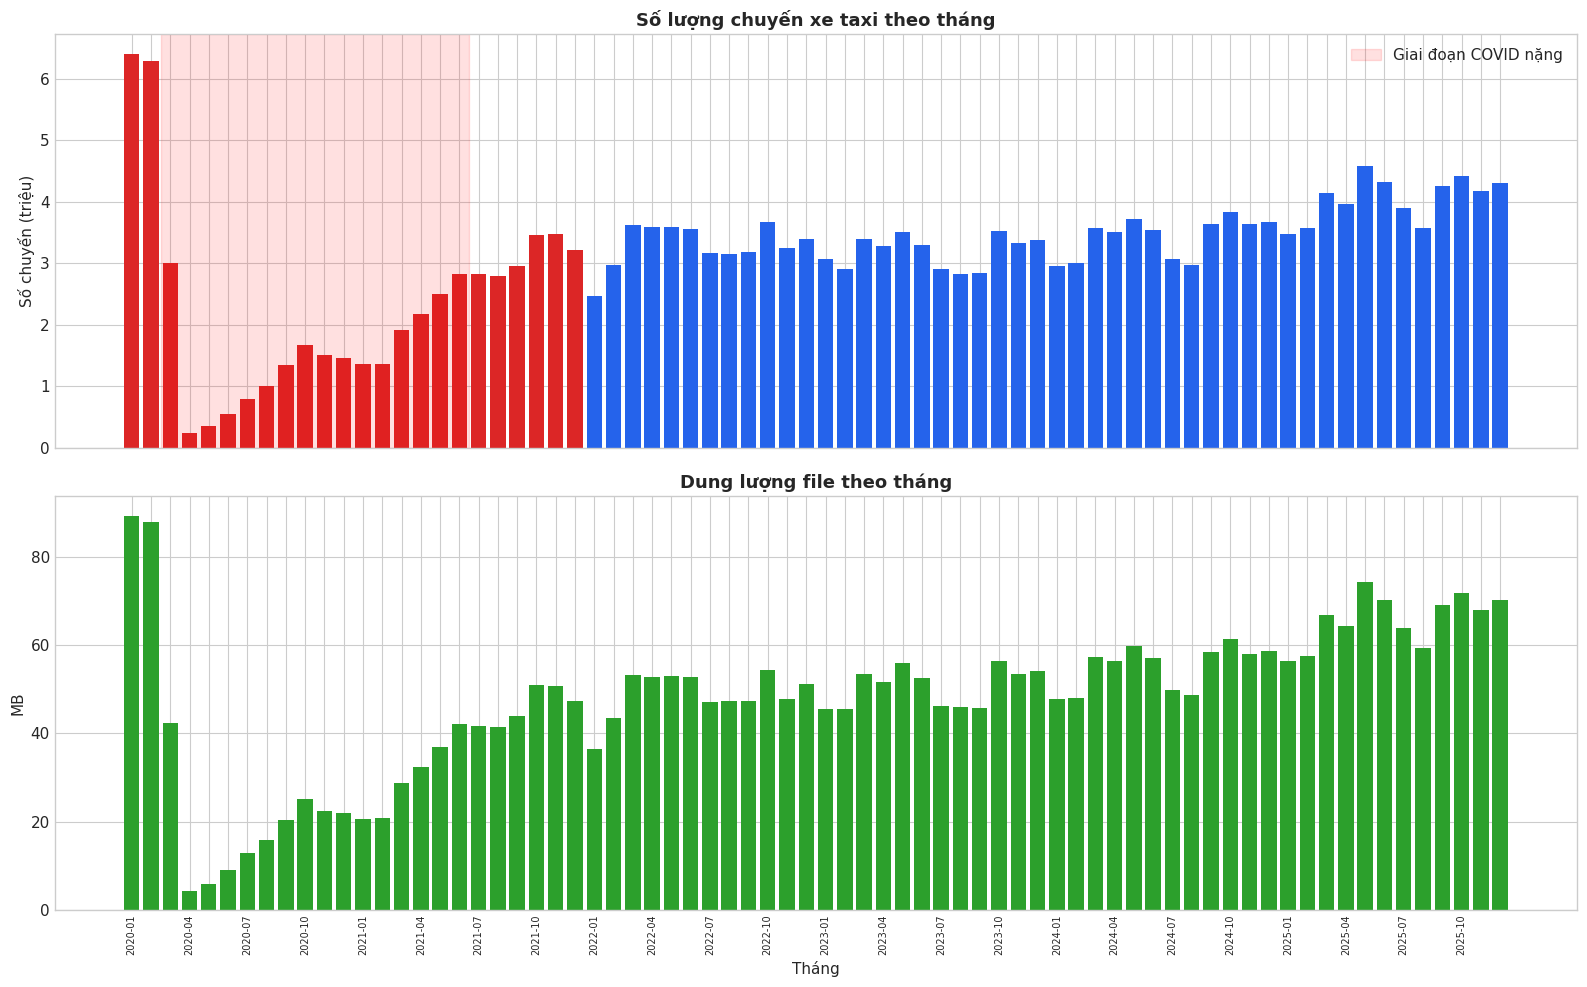

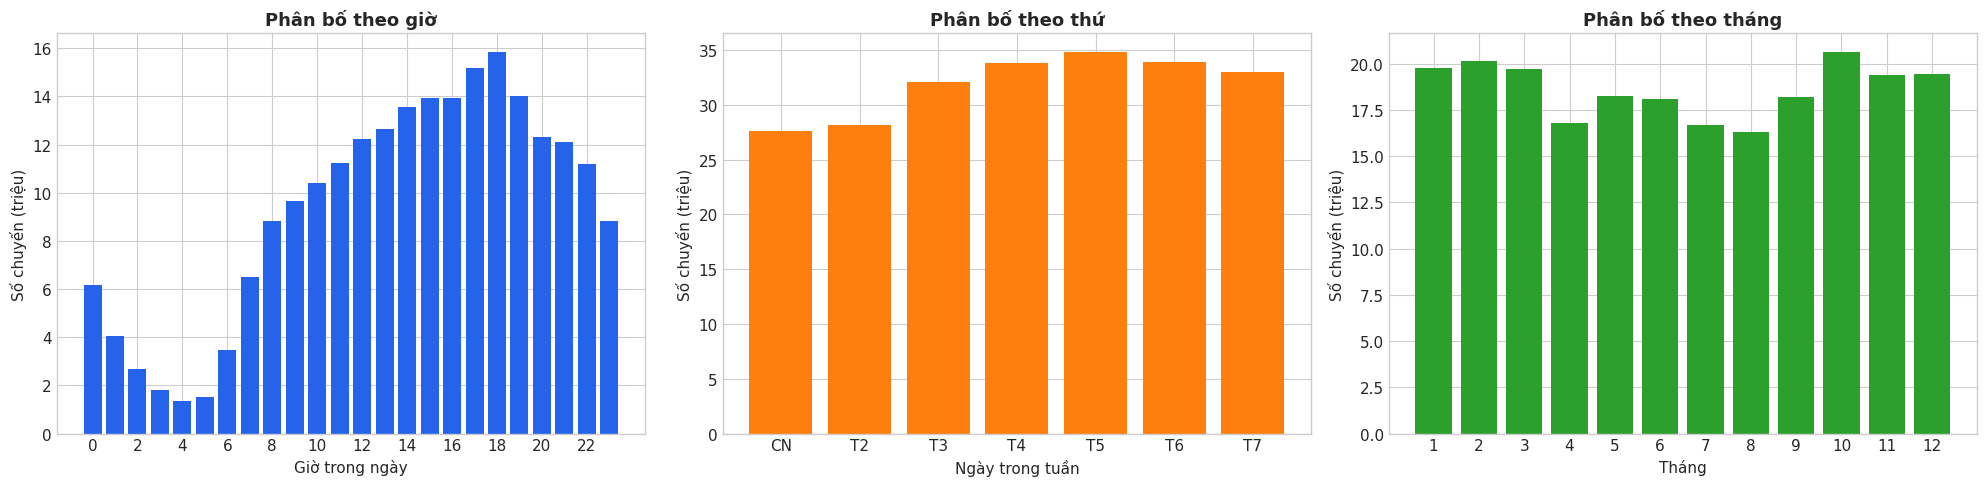

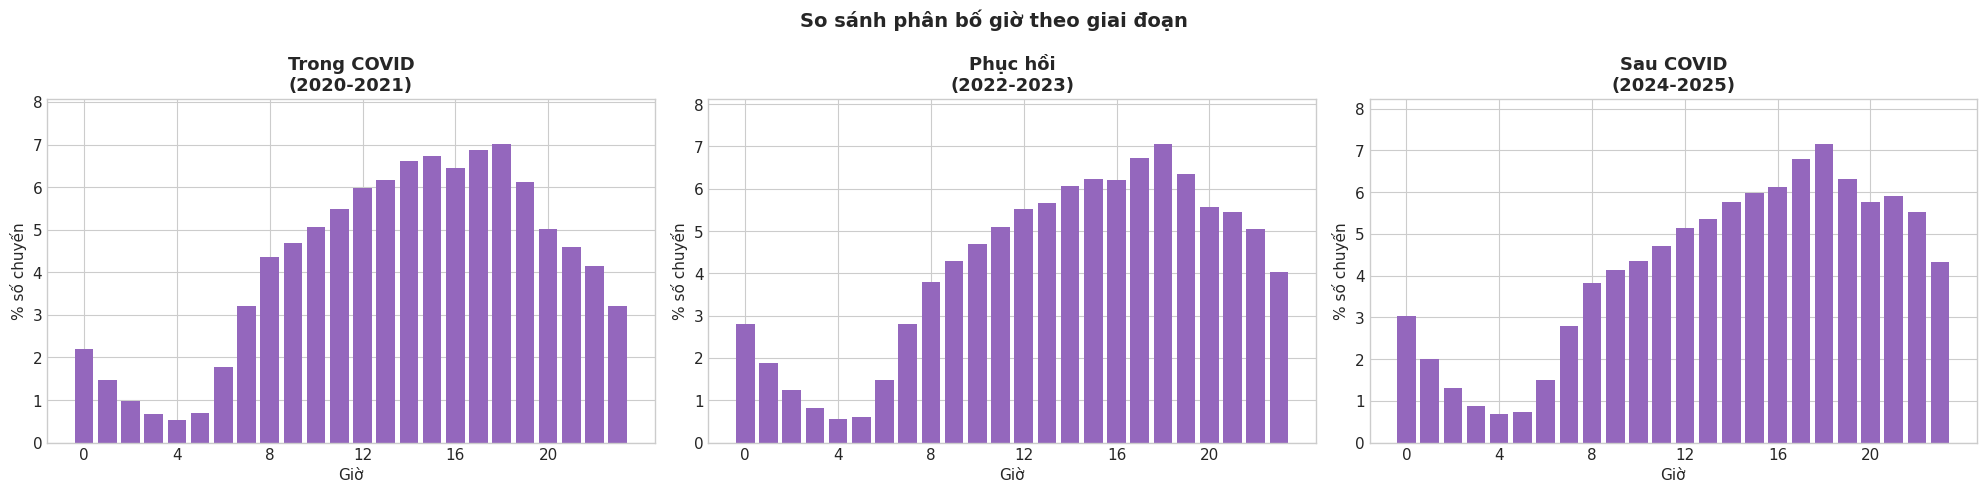

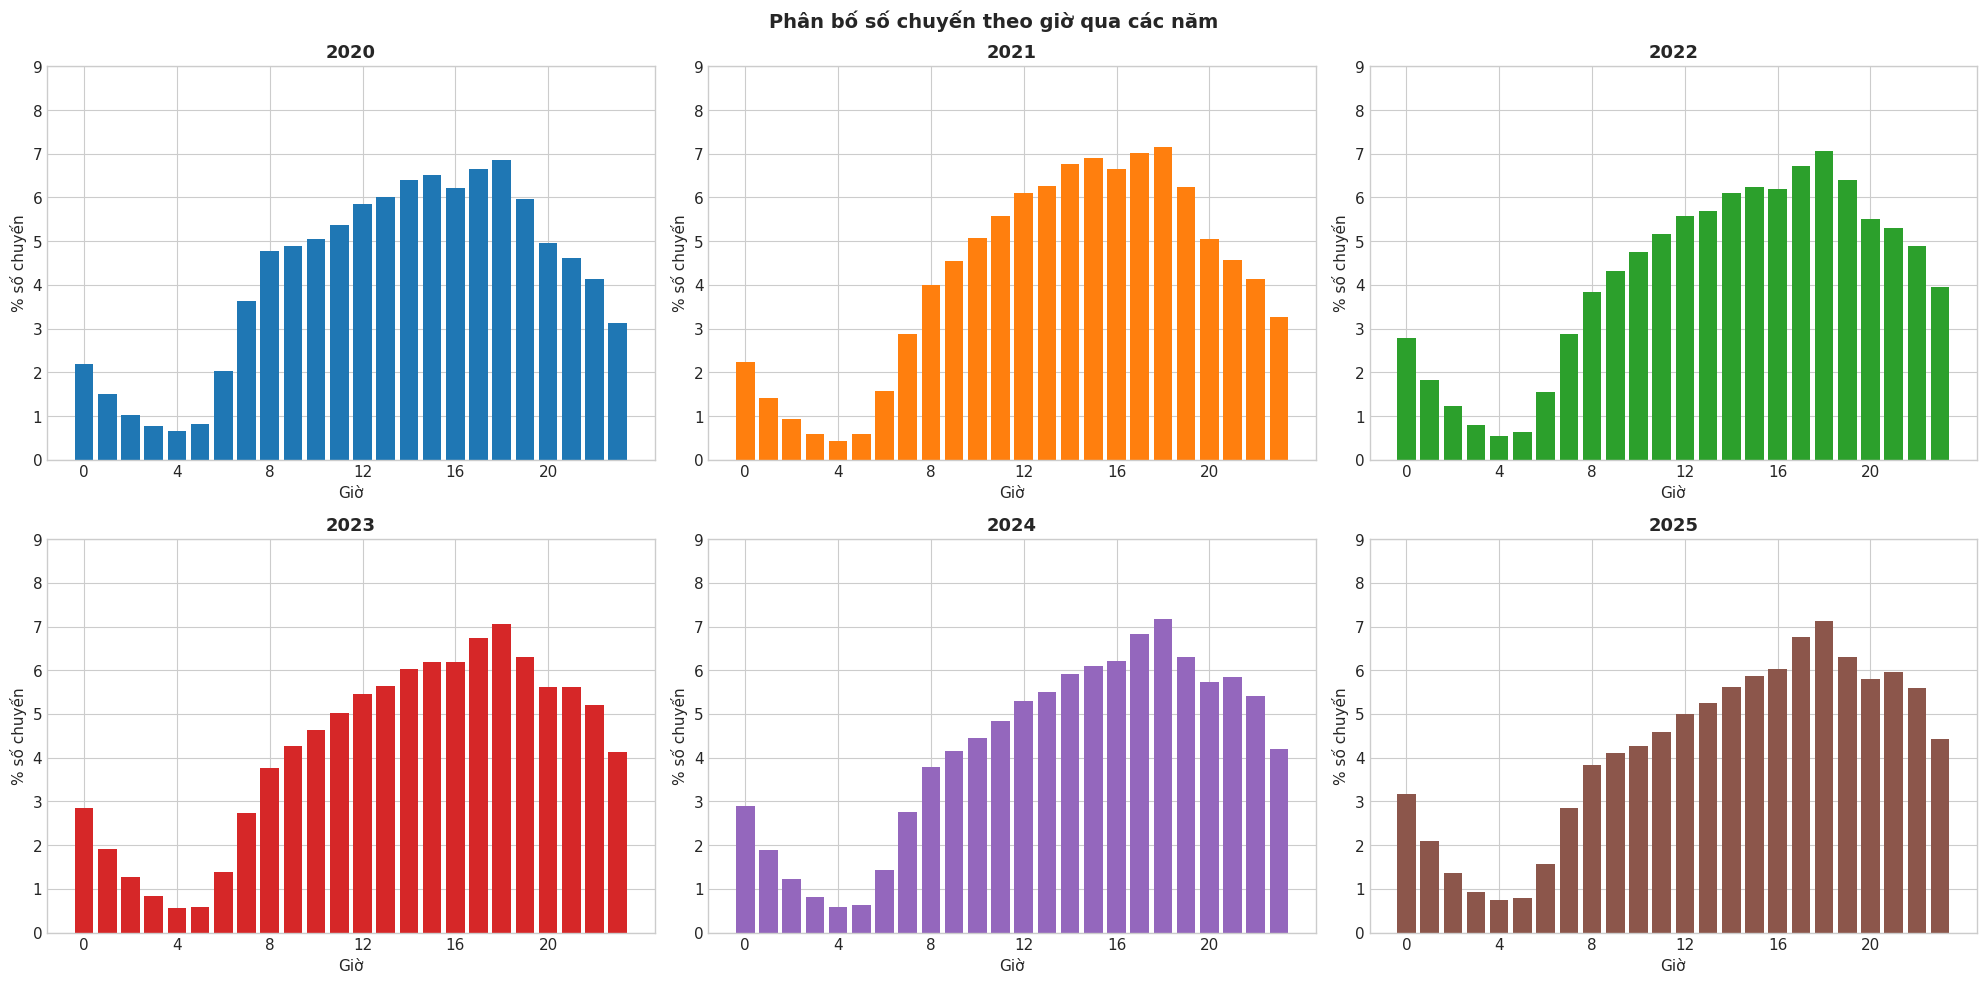


Biến động số chuyến theo năm:
  2020:   24,648,812 chuyến  ====================
  2021:   30,903,934 chuyến  ========================= (+25.4%)
  2022:   39,655,537 chuyến  ================================ (+28.3%)
  2023:   38,310,122 chuyến  =============================== (-3.4%)
  2024:   41,169,664 chuyến  ================================= (+7.5%)
  2025:   48,722,573 chuyến  ======================================== (+18.3%)


In [5]:
# ====================================================================
# PHẦN 2 -- PHÂN TÍCH THỜI GIAN
# ====================================================================
print(" PHẦN 2 -- PHÂN TÍCH THỜI GIAN")
 
# 2a. Số chuyến và dung lượng file theo tháng
df_files["ym"] = df_files["year"].astype(str) + "-" + df_files["month"].apply(lambda m: f"{m:02d}")
 
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
colors = [COLOR_WARN if 2020 <= y <= 2021 else COLOR_PRIMARY for y in df_files["year"]]
 
axes[0].bar(df_files["ym"], df_files["row_count"] / 1e6, color=colors, edgecolor="none", width=0.8)
axes[0].set_ylabel("Số chuyến (triệu)")
axes[0].set_title("Số lượng chuyến xe taxi theo tháng")
if len(df_files[df_files["ym"] == "2020-03"]) and len(df_files[df_files["ym"] == "2021-06"]):
    axes[0].axvspan(
        df_files[df_files["ym"] == "2020-03"].index[0] - 0.5,
        df_files[df_files["ym"] == "2021-06"].index[-1] + 0.5,
        alpha=0.12, color="red", label="Giai đoạn COVID nặng"
    )
    axes[0].legend()
 
axes[1].bar(df_files["ym"], df_files["size_mb"], color="#2ca02c", edgecolor="none", width=0.8)
axes[1].set_ylabel("MB"); axes[1].set_xlabel("Tháng")
axes[1].set_title("Dung lượng file theo tháng")
 
for ax in axes:
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    for i, lbl in enumerate(ax.get_xticklabels()):
        if i % 3 != 0: lbl.set_visible(False)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02a_so_chuyen_dung_luong.png"), dpi=150)
plt.show()
 
# 2b. Chu kỳ giờ / thứ / tháng
hourly_pdf  = pd.DataFrame(sorted(hourly_agg.items()), columns=["hr", "count"])
dow_pdf     = pd.DataFrame(sorted(dow_agg.items()), columns=["dow", "count"])
monthly_pdf = pd.DataFrame(sorted(monthly_agg.items()), columns=["mon", "count"])
 
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
 
axes[0].bar(hourly_pdf["hr"], hourly_pdf["count"] / 1e6, color=COLOR_PRIMARY, edgecolor="none")
axes[0].set_xlabel("Giờ trong ngày"); axes[0].set_ylabel("Số chuyến (triệu)")
axes[0].set_title("Phân bố theo giờ"); axes[0].set_xticks(range(0, 24, 2))
 
dow_labels = ["CN", "T2", "T3", "T4", "T5", "T6", "T7"]  # Spark: 1=CN
axes[1].bar(dow_labels, dow_pdf["count"] / 1e6, color="#ff7f0e", edgecolor="none")
axes[1].set_xlabel("Ngày trong tuần"); axes[1].set_ylabel("Số chuyến (triệu)")
axes[1].set_title("Phân bố theo thứ")
 
axes[2].bar(monthly_pdf["mon"], monthly_pdf["count"] / 1e6, color="#2ca02c", edgecolor="none")
axes[2].set_xlabel("Tháng"); axes[2].set_ylabel("Số chuyến (triệu)")
axes[2].set_title("Phân bố theo tháng"); axes[2].set_xticks(range(1, 13))
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02b_chu_ky.png"), dpi=150)
plt.show()
 
# 2c. So sánh phân bố giờ theo giai đoạn COVID
year_hour_pdf = pd.DataFrame(
    [(yr, hr, c) for (yr, hr), c in year_hour_agg.items()],
    columns=["yr", "hr", "count"]
)
 
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
periods = {
    "Trong COVID\n(2020-2021)": [2020, 2021],
    "Phục hồi\n(2022-2023)":    [2022, 2023],
    "Sau COVID\n(2024-2025)":   [2024, 2025],
}
 
for ax, (label, yrs) in zip(axes, periods.items()):
    sub = year_hour_pdf[year_hour_pdf["yr"].isin(yrs)].groupby("hr")["count"].sum().reset_index()
    total = sub["count"].sum()
    sub["pct"] = sub["count"] / total * 100 if total > 0 else 0
    ax.bar(sub["hr"], sub["pct"], color="#9467bd", edgecolor="none")
    ax.set_title(label); ax.set_xlabel("Giờ"); ax.set_ylabel("% số chuyến")
    ax.set_xticks(range(0, 24, 4))
    if len(sub) and sub["pct"].max() > 0:
        ax.set_ylim(0, sub["pct"].max() * 1.15)
 
plt.suptitle("So sánh phân bố giờ theo giai đoạn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02c_covid_theo_gio.png"), dpi=150)
plt.show()
 
# 2d. Phân bố giờ theo từng năm
n_years = len(list(YEARS))
ncols = 3
nrows = (n_years + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes_flat = axes.flatten()
 
for idx, yr in enumerate(YEARS):
    ax = axes_flat[idx]
    sub = year_hour_pdf[year_hour_pdf["yr"] == yr].sort_values("hr")
    if len(sub) and sub["count"].sum() > 0:
        sub = sub.copy()
        sub["pct"] = sub["count"] / sub["count"].sum() * 100
        ax.bar(sub["hr"], sub["pct"], color=plt.cm.tab10(idx), edgecolor="none")
        ax.set_title(f"{yr}"); ax.set_xticks(range(0, 24, 4)); ax.set_ylim(0, 9)
        ax.set_xlabel("Giờ"); ax.set_ylabel("% số chuyến")
for i in range(len(list(YEARS)), len(axes_flat)):
    axes_flat[i].set_visible(False)
 
plt.suptitle("Phân bố số chuyến theo giờ qua các năm", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02d_gio_theo_nam.png"), dpi=150)
plt.show()
 
# Biến động theo năm
print("\nBiến động số chuyến theo năm:")
rows_by_year = df_files.groupby("year")["row_count"].sum()
for yr in YEARS:
    r = rows_by_year.get(yr, 0)
    mx = rows_by_year.max() if rows_by_year.max() > 0 else 1
    bar = "=" * int(r / mx * 40)
    prev = rows_by_year.get(yr - 1, None)
    chg = f" ({(r - prev) / prev * 100:+.1f}%)" if prev and prev > 0 else ""
    print(f"  {yr}: {r:>12,} chuyến  {bar}{chg}")

### Nhận xét Tổng thể Kết quả Phân tích Thời gian Dữ liệu Taxi NYC

**1. Biểu đồ: Số lượng chuyến và Dung lượng file theo tháng**
* **Tác động của đại dịch và sự phục hồi:** Sự kiện COVID-19 thể hiện rất rõ nét qua cú sụt giảm nghiêm trọng vào tháng 4/2020. Sau giai đoạn này, lượng chuyến đi (biểu đồ trên) tăng trưởng đều đặn trở lại nhưng đến năm 2025 vẫn chưa hoàn toàn chạm lại mức đỉnh của đầu năm 2020.
* **Sự phình to của dữ liệu:** Điểm đáng chú ý nhất là từ năm 2022, dung lượng file (biểu đồ dưới) bắt đầu tăng vọt và vượt xa mức của năm 2020, mặc dù số lượng chuyến đi ít hơn. Điều này chỉ ra rằng hệ thống thu thập đã ghi nhận thêm nhiều thông tin hơn (thêm cột dữ liệu) hoặc thay đổi định dạng lưu trữ cho mỗi chuyến đi kể từ năm 2022.

**2. Biểu đồ: Chu kỳ Giờ / Thứ / Tháng**
* **Theo giờ:** Nhu cầu đi lại bám sát lịch trình sinh hoạt đô thị, bắt đầu tăng từ 6h sáng, duy trì mức cao trong ngày và đạt đỉnh điểm vào khung giờ tan tầm (17h - 19h).
* **Theo thứ trong tuần:** Khối lượng chuyến đi tập trung mạnh vào nửa cuối tuần (Thứ 5, Thứ 6 và Thứ 7), phản ánh sự kết hợp giữa nhu cầu đi làm và các hoạt động vui chơi, giải trí cuối tuần của người dân New York.
* **Theo tháng:** Nhịp độ khá đồng đều nhưng có xu hướng chững lại vào giữa mùa hè (tháng 7, 8) và bận rộn nhất vào các tháng mùa thu/đầu đông (tháng 10, 5).

**3. Biểu đồ: So sánh phân bố giờ theo giai đoạn COVID**
* **Sự thay đổi cấu trúc sinh hoạt:** Giai đoạn "Trong COVID" (2020-2021) có đường cong phân bố khá phẳng, không có đỉnh nhọn rõ rệt vào chiều tối, phản ánh xu hướng làm việc từ nhà (Work From Home) và các lệnh hạn chế ra đường buổi tối. 
* **Trở lại trạng thái bình thường mới:** Bước sang giai đoạn "Phục hồi" và "Sau COVID", biểu đồ đã lấy lại hình dáng chuẩn với đỉnh nhọn vào lúc 17h-18h. Điều này chứng tỏ người dân đã quay trở lại văn phòng và nhịp điệu sinh hoạt truyền thống đã được khôi phục.

**4. Biểu đồ: Phân bố số chuyến theo giờ qua từng năm (2020 - 2025)**
* **Chi tiết hóa sự chuyển dịch:** Năm 2020 có hình thái phân bố bất thường nhất. Bắt đầu từ 2021, đồ thị dần định hình lại.
* **Sự ổn định:** Giai đoạn 2022 - 2025 cho thấy hình thái phân bố gần như y hệt nhau, khẳng định giao thông New York đã tìm được điểm cân bằng mới và duy trì tính quy luật rất cao trong những năm gần đây. Một điểm nhỏ là tỷ trọng các chuyến đi vào rạng sáng (0h - 4h) vẫn ở mức tương đối thấp so với tỷ trọng ban ngày.

 PHẦN 3 -- PHÂN TÍCH KHÔNG GIAN

TOP 20 KHU VỰC ĐÓN KHÁCH:
 LocationID  Pickup_Count                         Zone   Borough
        237      10390685        Upper East Side South Manhattan
        132       9615438                  JFK Airport    Queens
        161       9381553               Midtown Center Manhattan
        236       9371584        Upper East Side North Manhattan
        186       7386385 Penn Station/Madison Sq West Manhattan
        162       7359246                 Midtown East Manhattan
        142       6992179          Lincoln Square East Manhattan
        230       6808162    Times Sq/Theatre District Manhattan
        170       6538858                  Murray Hill Manhattan
        239       6191924        Upper West Side South Manhattan
        138       6069308            LaGuardia Airport    Queens
        163       6043832                Midtown North Manhattan
         48       6031501                 Clinton East Manhattan
        234       5972623      

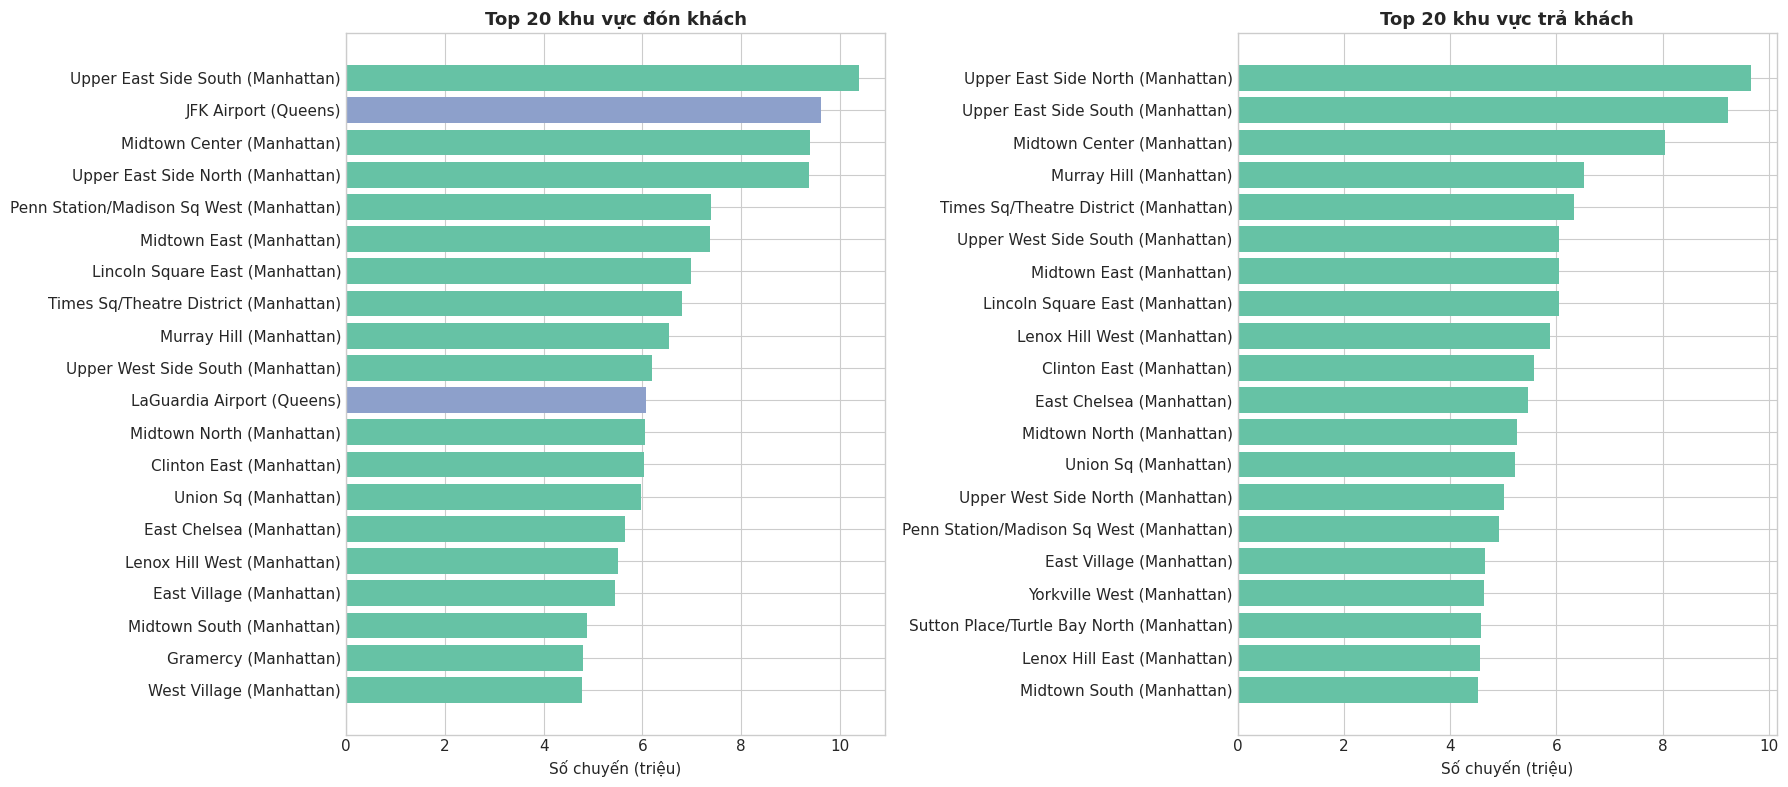


TOP 30 TUYẾN ĐƯỜNG PHỔ BIẾN NHẤT:
 PU  DO  Trip_Count                      PU_Name                   DO_Name   PU_Boro   DO_Boro
237 236     1498844        Upper East Side South     Upper East Side North Manhattan Manhattan
236 237     1283424        Upper East Side North     Upper East Side South Manhattan Manhattan
161 237      639089               Midtown Center     Upper East Side South Manhattan Manhattan
237 161      625998        Upper East Side South            Midtown Center Manhattan Manhattan
239 142      556304        Upper West Side South       Lincoln Square East Manhattan Manhattan
239 238      555258        Upper West Side South     Upper West Side North Manhattan Manhattan
142 239      553938          Lincoln Square East     Upper West Side South Manhattan Manhattan
161 236      545059               Midtown Center     Upper East Side North Manhattan Manhattan
237 162      531757        Upper East Side South              Midtown East Manhattan Manhattan
141 236      52

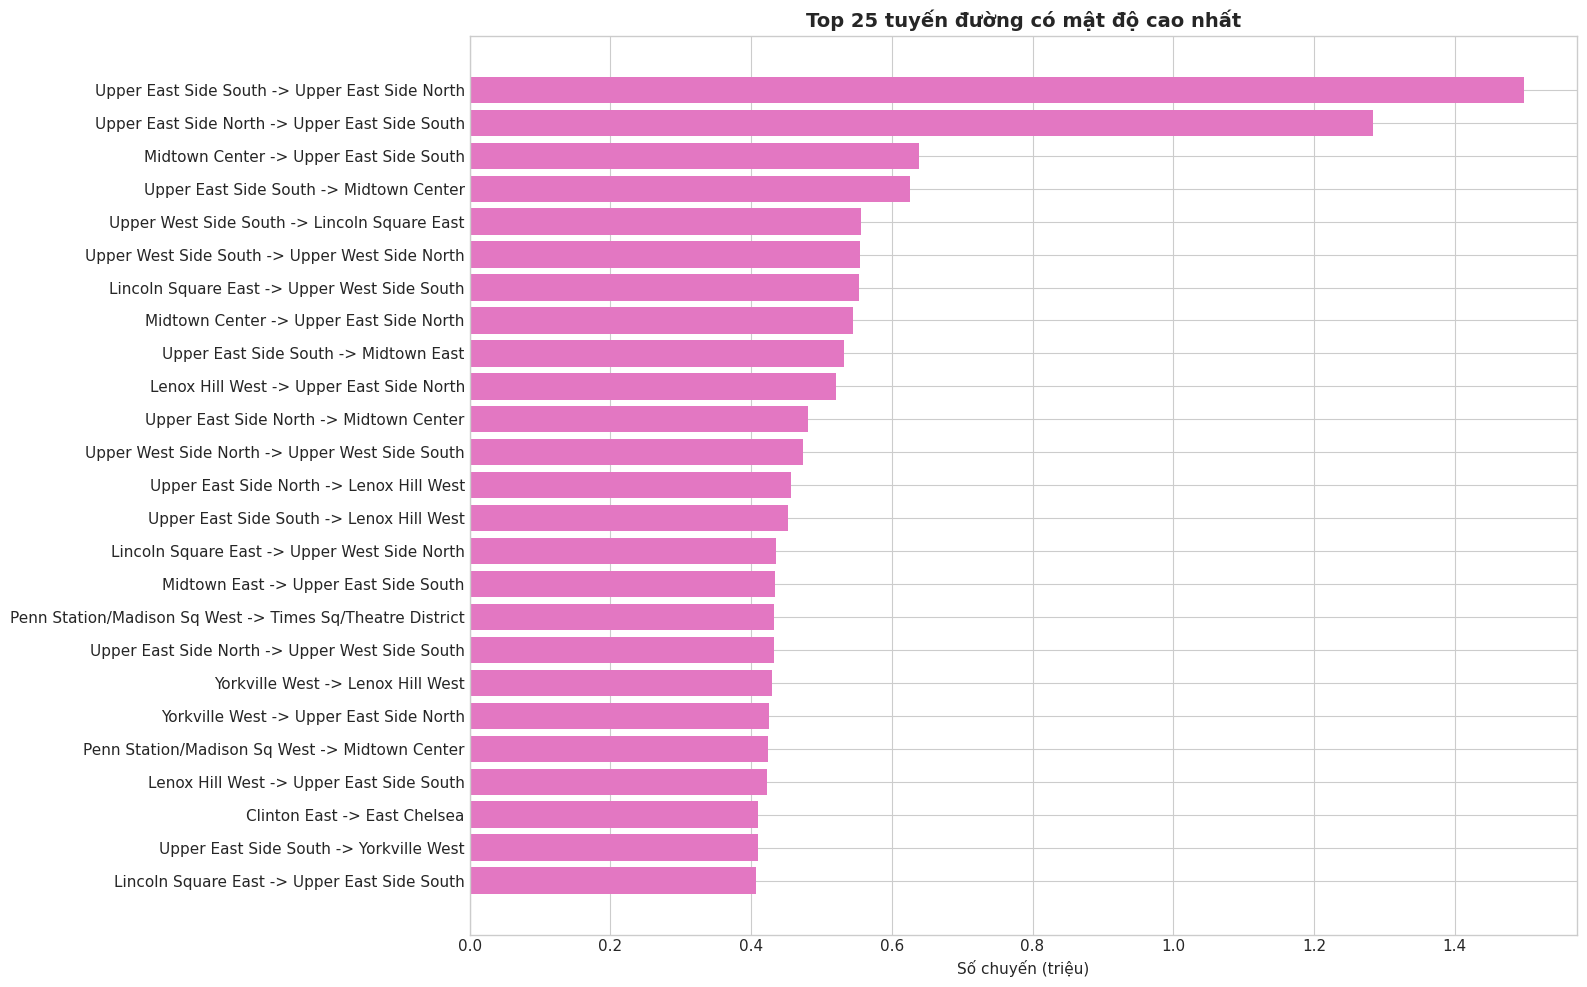

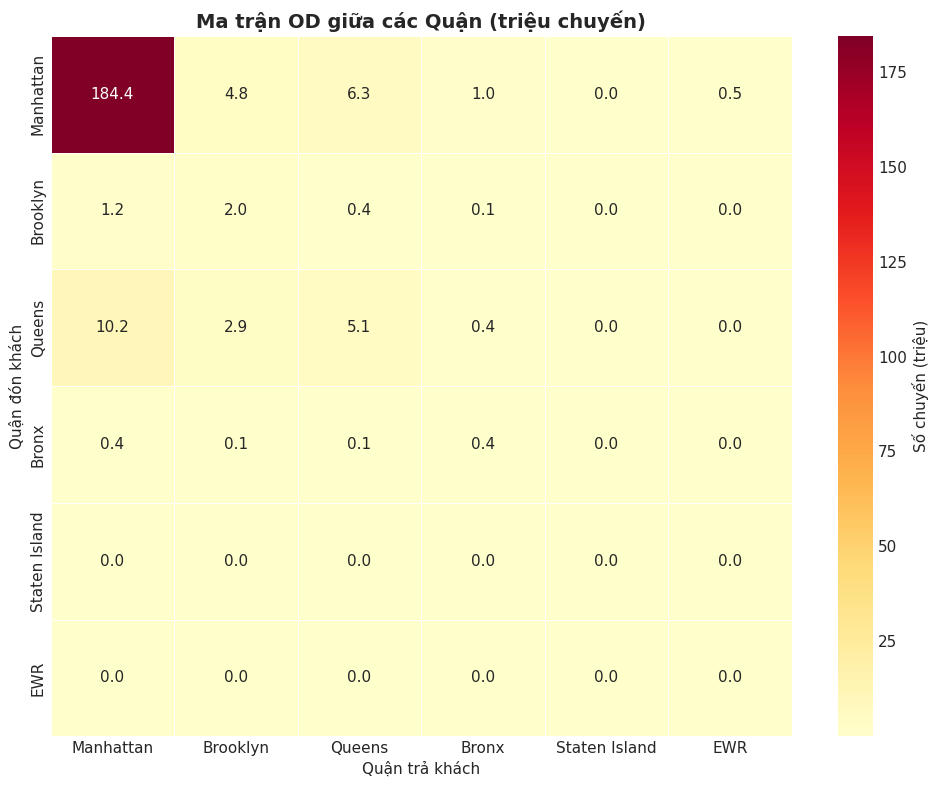


Số chuyến đón khách theo Quận và Năm (triệu):
borough  Bronx  Brooklyn   EWR  Manhattan  Queens  Staten Island
year                                                            
2020      0.15      0.40  0.00      22.46    1.41            0.0
2021      0.13      0.36  0.00      27.93    2.11            0.0
2022      0.05      0.29  0.01      35.28    3.45            0.0
2023      0.07      0.28  0.01      33.81    3.76            0.0
2024      0.13      0.60  0.01      36.40    3.89            0.0
2025      0.38      1.77  0.01      41.82    4.64            0.0


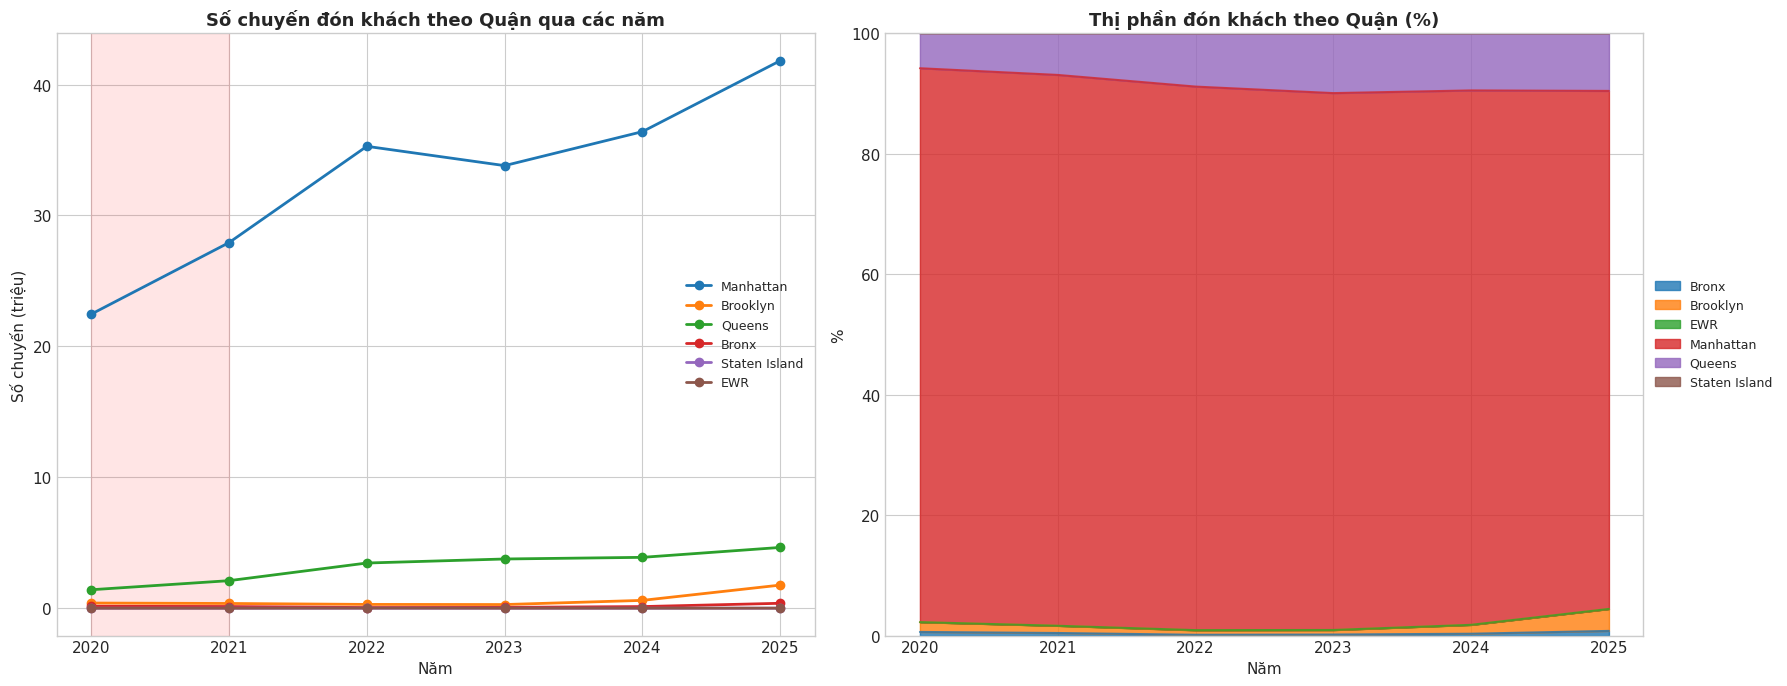


SO SÁNH QUẬN: Giai đoạn COVID vs Sau COVID:
                 tb_covid  tb_sau_covid  phuc_hoi_%
borough                                            
Brooklyn         379779.5     1183661.0       311.7
Queens          1758572.5     4265221.5       242.5
EWR                2564.5        5998.0       233.9
Bronx            139293.5      252229.5       181.1
Manhattan      25195047.0    39111105.5       155.2
Staten Island      3663.0        3281.0        89.6
Unknown          198635.5      101536.5        51.1
N/A               98817.5       23085.5        23.4


In [6]:
# PHẦN 3 -- PHÂN TÍCH KHÔNG GIAN
print(" PHẦN 3 -- PHÂN TÍCH KHÔNG GIAN")

# 3a. Top khu vực đón / trả khách
pu_pdf = pd.DataFrame(
    [(k, v) for k, v in pu_agg.items()], columns=["LocationID", "Pickup_Count"]
).sort_values("Pickup_Count", ascending=False)
pu_pdf["Zone"]    = pu_pdf["LocationID"].map(get_zone_name)
pu_pdf["Borough"] = pu_pdf["LocationID"].map(get_borough)
 
do_pdf = pd.DataFrame(
    [(k, v) for k, v in do_agg.items()], columns=["LocationID", "Dropoff_Count"]
).sort_values("Dropoff_Count", ascending=False)
do_pdf["Zone"]    = do_pdf["LocationID"].map(get_zone_name)
do_pdf["Borough"] = do_pdf["LocationID"].map(get_borough)
 
print("\nTOP 20 KHU VỰC ĐÓN KHÁCH:")
print(pu_pdf.head(20).to_string(index=False))
print("\nTOP 20 KHU VỰC TRẢ KHÁCH:")
print(do_pdf.head(20).to_string(index=False))
 
pu_pdf.to_csv(os.path.join(OUT_DIR, "03a_khu_vuc_don.csv"), index=False)
do_pdf.to_csv(os.path.join(OUT_DIR, "03a_khu_vuc_tra.csv"), index=False)
 
# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
b_colors = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island", "EWR", "Unknown"]
 
for ax_i, (df_t, col, title) in enumerate([
    (pu_pdf, "Pickup_Count", "Top 20 khu vực đón khách"),
    (do_pdf, "Dropoff_Count", "Top 20 khu vực trả khách"),
]):
    top20 = df_t.head(20).iloc[::-1]
    cl = [sns.color_palette("Set2")[b_colors.index(b) if b in b_colors else 6] for b in top20["Borough"]]
    axes[ax_i].barh([f"{r.Zone} ({r.Borough})" for _, r in top20.iterrows()],
                     top20[col] / 1e6, color=cl, edgecolor="none")
    axes[ax_i].set_xlabel("Số chuyến (triệu)"); axes[ax_i].set_title(title)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "03a_top_khu_vuc.png"), dpi=150)
plt.show()
 
# 3b. Top tuyến đường phổ biến
route_pdf = pd.DataFrame(
    [(k[0], k[1], v) for k, v in route_agg.items()],
    columns=["PU", "DO", "Trip_Count"]
).sort_values("Trip_Count", ascending=False)
route_pdf["PU_Name"] = route_pdf["PU"].map(get_zone_name)
route_pdf["DO_Name"] = route_pdf["DO"].map(get_zone_name)
route_pdf["PU_Boro"] = route_pdf["PU"].map(get_borough)
route_pdf["DO_Boro"] = route_pdf["DO"].map(get_borough)

# ── LỌC BỎ N/A VÀ TUYẾN CÙNG ĐIỂM ──
route_pdf = route_pdf[
    (route_pdf["PU_Name"] != "N/A") &
    (route_pdf["DO_Name"] != "N/A") &
    (route_pdf["PU"] != route_pdf["DO"])
].reset_index(drop=True)

print("\nTOP 30 TUYẾN ĐƯỜNG PHỔ BIẾN NHẤT:")
print(route_pdf.head(30).to_string(index=False))
route_pdf.head(100).to_csv(os.path.join(OUT_DIR, "03b_top_tuyen_duong.csv"), index=False)

fig, ax = plt.subplots(figsize=(16, 10))
tr = route_pdf.head(25).iloc[::-1]
ax.barh([f"{r.PU_Name} -> {r.DO_Name}" for _, r in tr.iterrows()],
         tr["Trip_Count"] / 1e6, color="#e377c2", edgecolor="none")
ax.set_xlabel("Số chuyến (triệu)")
ax.set_title("Top 25 tuyến đường có mật độ cao nhất", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "03b_top_tuyen_duong.png"), dpi=150)
plt.show()
# 3c. Ma trận OD giữa các Quận
boroughs_list = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island", "EWR"]
od_matrix = pd.DataFrame(0, index=boroughs_list, columns=boroughs_list)
for (b_pu, b_do), cnt in borough_od_agg.items():
    if b_pu in boroughs_list and b_do in boroughs_list:
        od_matrix.loc[b_pu, b_do] = cnt
 
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(od_matrix / 1e6, annot=True, fmt=".1f", cmap="YlOrRd",
            ax=ax, linewidths=0.5, cbar_kws={"label": "Số chuyến (triệu)"})
ax.set_title("Ma trận OD giữa các Quận (triệu chuyến)", fontsize=14, fontweight="bold")
ax.set_xlabel("Quận trả khách"); ax.set_ylabel("Quận đón khách")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "03c_ma_tran_od.png"), dpi=150)
plt.show()
 
# 3d. Xu hướng các Quận qua các năm
borough_year_data = []
for (yr, b), c in borough_pu_year_agg.items():
    do_c = borough_do_year_agg.get((yr, b), 0)
    borough_year_data.append({"year": yr, "borough": b, "pickups": c, "dropoffs": do_c})
df_borough = pd.DataFrame(borough_year_data)
 
pivot_pu = df_borough[df_borough["borough"].isin(boroughs_list)] \
    .pivot_table(index="year", columns="borough", values="pickups", aggfunc="sum").fillna(0)
 
print("\nSố chuyến đón khách theo Quận và Năm (triệu):")
print((pivot_pu / 1e6).round(2).to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for b in boroughs_list:
    if b in pivot_pu.columns:
        axes[0].plot(pivot_pu.index, pivot_pu[b] / 1e6, marker="o", label=b, linewidth=2)
axes[0].set_title("Số chuyến đón khách theo Quận qua các năm")
axes[0].set_ylabel("Số chuyến (triệu)"); axes[0].set_xlabel("Năm")
axes[0].legend(fontsize=9); axes[0].axvspan(2020, 2021, alpha=0.1, color="red")
 
pivot_pct = pivot_pu.div(pivot_pu.sum(axis=1), axis=0) * 100
pivot_pct.plot.area(ax=axes[1], stacked=True, alpha=0.8)
axes[1].set_title("Thị phần đón khách theo Quận (%)")
axes[1].set_ylabel("%"); axes[1].set_xlabel("Năm"); axes[1].set_ylim(0, 100)
axes[1].legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "03d_xu_huong_quan.png"), dpi=150, bbox_inches="tight")
plt.show()
 
df_borough.to_csv(os.path.join(OUT_DIR, "03d_quan_theo_nam.csv"), index=False)
 
# 3e. So sánh phục hồi sau COVID
print("\nSO SÁNH QUẬN: Giai đoạn COVID vs Sau COVID:")
pre  = df_borough[df_borough["year"].isin([2020, 2021])].groupby("borough")["pickups"].mean()
post = df_borough[df_borough["year"].isin([2024, 2025])].groupby("borough")["pickups"].mean()
comp = pd.DataFrame({"tb_covid": pre, "tb_sau_covid": post,
                      "phuc_hoi_%": (post / pre * 100).round(1)})
comp = comp.sort_values("phuc_hoi_%", ascending=False)
print(comp.to_string())
comp.to_csv(os.path.join(OUT_DIR, "03e_phuc_hoi_covid.csv"))

### Nhận xét Tổng thể Kết quả Phân tích Không gian Dữ liệu Taxi NYC

**1. Khu vực đón và trả khách phổ biến nhất (Hình 3a)**
* **Sự thống trị tuyệt đối của Manhattan:** Cả hai danh sách Top 20 điểm đón và trả khách gần như bị "phủ xanh" hoàn toàn bởi các khu vực thuộc quận Manhattan (đặc biệt là Upper East Side, Midtown, Penn Station, và Times Square). Điều này cho thấy Yellow Taxi phục vụ chủ yếu cho lõi trung tâm thương mại và du lịch của thành phố.
* **Tầm quan trọng của các Sân bay (Queens):** Điểm sáng duy nhất ngoài Manhattan lọt vào Top là Sân bay JFK và LaGuardia (quận Queens). Đáng chú ý, lượng đón khách tại JFK xếp hạng thứ 2 toàn thành phố, cho thấy việc đưa đón sân bay là một mảng kinh doanh cốt lõi của dòng taxi vàng.

**2. Các tuyến đường có mật độ cao nhất (Hình 3b)**
* **Nhu cầu di chuyển cự ly siêu ngắn:** Các tuyến đường dẫn đầu về số chuyến (Trip_Count > 1 triệu) đều là các chuyến đi nội bộ giữa các khu vực nằm sát nhau, ví dụ điển hình là `Upper East Side South <-> Upper East Side North`. Điều này phản ánh thói quen sử dụng taxi để di chuyển những quãng đường rất ngắn của người dân ở các khu nhà giàu hoặc trung tâm thương mại.


**3. Ma trận Origin-Destination (OD) giữa các Quận (Hình 3c)**
* **Sự phân bổ bất đối xứng cực đoan:** Heatmap chỉ ra một thực tế rực rỡ nhất ở ô `Manhattan -> Manhattan` với 184.4 triệu chuyến. Giao thông nội quận Manhattan chiếm tỷ trọng áp đảo hoàn toàn so với toàn bộ phần còn lại của New York.
* **Trục giao thông chính thứ hai:** Luồng di chuyển liên quận đáng kể nhất là giữa Manhattan và Queens (10.2 triệu chuyến từ Queens về Manhattan và 6.3 triệu chuyến chiều ngược lại). Đây chắc chắn là luồng khách trung chuyển từ hai sân bay lớn (JFK, LGA) vào trung tâm thành phố. Các quận như Staten Island hay Bronx gần như không sử dụng Yellow Taxi.

**4. Xu hướng các Quận và Tốc độ phục hồi sau COVID (Hình 3d & Dữ liệu 3e)**
* **Biến động Thị phần:** Mặc dù số chuyến đi thay đổi mạnh qua các năm do dịch bệnh, nhưng cơ cấu thị phần gần như bất di bất dịch: Manhattan luôn chiếm trên 90% miếng bánh, phần còn lại chủ yếu thuộc về Queens.
* **Tốc độ phục hồi nghịch lý:** Dữ liệu so sánh trước và sau COVID (bảng 3e) mang lại một insight rất thú vị. Mặc dù Manhattan có tổng số chuyến lớn nhất, nhưng tỷ lệ phục hồi của nó chỉ đạt **155.2%**. Trong khi đó, khu vực ngoại vi như **Brooklyn (311.7%)** và **Queens (242.5%)** lại có mức tăng trưởng ngoạn mục hơn rất nhiều so với thời kỳ đáy COVID. Điều này có thể là hệ quả của xu hướng dịch chuyển nơi ở ra xa trung tâm hoặc sự thay đổi trong thói quen làm việc từ xa, khiến nhu cầu di chuyển ở các quận vệ tinh tăng mạnh.

In [7]:
spark.catalog.clearCache()
spark.stop()
